[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shuva\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shuva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shuva\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\shuva\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Device: cuda
Original shape: (392510, 9)
                       MedicineName           MedicineFor ReviewDate  \
0  12 Hour Nasal Decongestant Spray  For Nasal Congestion  26-Jan-21   
1  12 Hour Nasal Decongestant Spray  For Nasal Congestion  19-Aug-22   
2  12 Hour Nasal Decongestant Spray  For Nasal Congestion  28-Apr-18   
3                             5-HTP           For Anxiety   3-May-20   
4                             5-HTP           For Anxiety  11-Jul-19   

   UserName                   IntakeTime  \
0      xano                Not Specified   
1  Breat...       Taken for 1 to 2 years   
2       Abe  Taken for less than 1 month   
3    Andres  Taken for less than 1 month   
4     Shawn                Not Specified   

                                             Reviews  ReviewLength  Rating  \
0  This is very effective IF you can get the cove...            52       6   
1  Actually I use the generic brand of the 12 hou...           319      10   
2  Cap took 20 minutes to o

C:\Users\shuva\AppData\Local\Temp\ipykernel_2688\2272438464.py:508: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_bilstm_paper_style.p


Final Paper-Style BiLSTM + Metadata + GloVe300 Results
Accuracy : 0.7765366501630238
Precision: 0.7606902947982791
Recall   : 0.7765366501630238
F1       : 0.7672305979869513

Classification Report
              precision    recall  f1-score   support

    negative       0.74      0.79      0.76     16810
     neutral       0.29      0.18      0.23      4353
    positive       0.84      0.86      0.85     28523

    accuracy                           0.78     49686
   macro avg       0.63      0.61      0.61     49686
weighted avg       0.76      0.78      0.77     49686



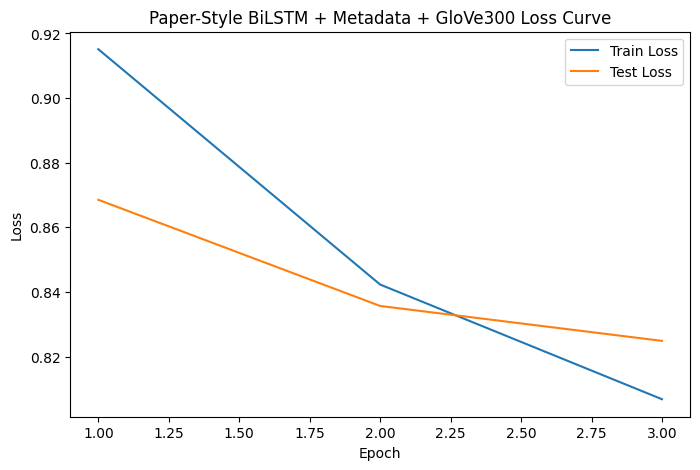

In [1]:
# =========================================================
# Full Pipeline:
# Paper-style preprocessing + GloVe300 + BiLSTM + Metadata
# 3-Class Sentiment Classification
# =========================================================

import pandas as pd
import numpy as np
import random
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# -------------------------
# 1. Download NLTK resources
# -------------------------
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# -------------------------
# 2. Reproducibility
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------------
# 3. File paths
# -------------------------
DATA_PATH = "DrugReviews.csv"          # change if needed
GLOVE_PATH = "glove.6B.300d.txt"       # change if needed

# -------------------------
# 4. Load raw dataset
# -------------------------
df = pd.read_csv(DATA_PATH)
print("Original shape:", df.shape)
print(df.head())

# -------------------------
# 5. Keep useful columns
# -------------------------
df = df[[
    "Reviews",
    "MedicineFor",
    "IntakeTime",
    "ReviewLength",
    "NumberOfLikes",
    "Rating"
]].copy()

# -------------------------
# 6. Remove missing values
# -------------------------
df.dropna(inplace=True)
print("After dropna:", df.shape)

# -------------------------
# 7. Remove duplicate reviews
# -------------------------
df.drop_duplicates(subset="Reviews", inplace=True)
print("After removing duplicate reviews:", df.shape)

# -------------------------
# 8. Paper-style clean_text function
# -------------------------
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).strip().lower()
    text = text.replace("\n", " ").replace("\r", " ")

    # keep words + apostrophes (important for sentiment)
    text = re.sub(r"[^a-zA-Z0-9\s']", " ", text)

    return text

df["Reviews"] = df["Reviews"].apply(clean_text)

# Remove empty reviews after cleaning
df = df[df["Reviews"].str.len() > 0].copy()
print("After text cleaning:", df.shape)

# -------------------------
# 9. Create 3-class labels
# -------------------------
def create_label(rating):
    if rating <= 4:
        return 0   # negative
    elif rating <= 6:
        return 1   # neutral
    else:
        return 2   # positive

df["label"] = df["Rating"].apply(create_label)

print("Label counts:")
print(df["label"].value_counts())

# -------------------------
# 10. Encode categorical metadata
# -------------------------
# Keep copies of original text columns if needed
medicine_encoder = LabelEncoder()
intake_encoder = LabelEncoder()

df["MedicineFor"] = medicine_encoder.fit_transform(df["MedicineFor"].astype(str))
df["IntakeTime"] = intake_encoder.fit_transform(df["IntakeTime"].astype(str))

# -------------------------
# 11. Scale numeric metadata
# -------------------------
scaler = StandardScaler()
df[["ReviewLength", "NumberOfLikes"]] = scaler.fit_transform(
    df[["ReviewLength", "NumberOfLikes"]]
)

print(df.head())

# -------------------------
# 12. Train-test split
# -------------------------
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train label counts:")
print(train_df["label"].value_counts())

# -------------------------
# 13. Build vocabulary from training text
# -------------------------
def tokenize(text):
    return text.split()

counter = Counter()
for text in train_df["Reviews"]:
    counter.update(tokenize(text))

MAX_VOCAB_SIZE = 40000
special_tokens = ["<PAD>", "<UNK>"]

most_common = counter.most_common(MAX_VOCAB_SIZE - len(special_tokens))
word_index = {word: idx + len(special_tokens) for idx, (word, _) in enumerate(most_common)}
word_index["<PAD>"] = 0
word_index["<UNK>"] = 1

print("Vocabulary size:", len(word_index))

# -------------------------
# 14. Paper-style create_embedding_matrix function
# -------------------------
def create_embedding_matrix(file_path, word_index, embedding_dim):
    vocab_size = len(word_index) + 1
    embedding_matrix = np.zeros((vocab_size, embedding_dim))

    with open(file_path, encoding="utf-8") as file:
        for line in file:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype="float32")

            if word in word_index:
                idx = word_index[word]
                embedding_matrix[idx] = vector[:embedding_dim]

    return embedding_matrix

EMBED_DIM = 300
embedding_matrix = create_embedding_matrix(
    file_path=GLOVE_PATH,
    word_index=word_index,
    embedding_dim=EMBED_DIM
)

# For words not found in GloVe, keep small random initialization instead of zeros
for word, idx in word_index.items():
    if not embedding_matrix[idx].any():
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(EMBED_DIM,))

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)
print("Embedding matrix shape:", embedding_matrix.shape)

# -------------------------
# 15. Convert text to sequences
# -------------------------
MAX_LEN = 260

def text_to_sequence(text, word_index, max_len=180):
    tokens = tokenize(text)
    seq = [word_index.get(token, word_index["<UNK>"]) for token in tokens]

    if len(seq) < max_len:
        seq = seq + [word_index["<PAD>"]] * (max_len - len(seq))
    else:
        seq = seq[:max_len]

    return seq

train_sequences = np.array([text_to_sequence(text, word_index, MAX_LEN) for text in train_df["Reviews"]])
test_sequences  = np.array([text_to_sequence(text, word_index, MAX_LEN) for text in test_df["Reviews"]])

# -------------------------
# 16. Metadata arrays
# -------------------------
X_train_meta = train_df[["ReviewLength", "NumberOfLikes"]].values.astype(np.float32)
X_test_meta  = test_df[["ReviewLength", "NumberOfLikes"]].values.astype(np.float32)

train_medicinefor = train_df["MedicineFor"].values.astype(np.int64)
test_medicinefor  = test_df["MedicineFor"].values.astype(np.int64)

train_intaketime = train_df["IntakeTime"].values.astype(np.int64)
test_intaketime  = test_df["IntakeTime"].values.astype(np.int64)

y_train = train_df["label"].values
y_test  = test_df["label"].values

print("Train text shape:", train_sequences.shape)
print("Train numeric meta shape:", X_train_meta.shape)

# -------------------------
# 17. Dataset class
# -------------------------
class HybridReviewDataset(Dataset):
    def __init__(self, text_sequences, meta_features, medicinefor, intaketime, labels):
        self.text_sequences = torch.tensor(text_sequences, dtype=torch.long)
        self.meta_features = torch.tensor(meta_features, dtype=torch.float32)
        self.medicinefor = torch.tensor(medicinefor, dtype=torch.long)
        self.intaketime = torch.tensor(intaketime, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.text_sequences[idx],
            self.meta_features[idx],
            self.medicinefor[idx],
            self.intaketime[idx],
            self.labels[idx]
        )

train_dataset = HybridReviewDataset(
    train_sequences,
    X_train_meta,
    train_medicinefor,
    train_intaketime,
    y_train
)

test_dataset = HybridReviewDataset(
    test_sequences,
    X_test_meta,
    test_medicinefor,
    test_intaketime,
    y_test
)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# -------------------------
# 18. BiLSTM + metadata model
# -------------------------
class BiLSTMAttentionWithMetadata(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_matrix,
        embed_dim,
        hidden_dim,
        output_dim,
        num_layers,
        dropout,
        medicinefor_vocab_size,
        intaketime_vocab_size,
        cat_embed_dim,
        numeric_input_dim,
        numeric_hidden_dim
    ):
        super(BiLSTMAttentionWithMetadata, self).__init__()

        # Text embedding
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=False,
            padding_idx=0
        )

        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Attention layer
        self.attention = nn.Linear(hidden_dim * 2, 1)

        # Metadata embeddings
        self.medicinefor_embedding = nn.Embedding(medicinefor_vocab_size + 1, cat_embed_dim)
        self.intaketime_embedding = nn.Embedding(intaketime_vocab_size + 1, cat_embed_dim)

        # Numeric metadata branch
        self.numeric_fc = nn.Sequential(
            nn.Linear(numeric_input_dim, numeric_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Final fusion
        fusion_dim = hidden_dim * 2 + cat_embed_dim + cat_embed_dim + numeric_hidden_dim

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(fusion_dim, output_dim)

    def forward(self, text, meta_numeric, medicinefor, intaketime):
        # text: [batch, seq_len]
        embedded = self.embedding(text)  # [batch, seq_len, embed_dim]

        # BiLSTM output
        lstm_out, _ = self.lstm(embedded)  # [batch, seq_len, hidden_dim*2]

        # Attention scores
        attn_scores = self.attention(lstm_out).squeeze(-1)  # [batch, seq_len]

        # Mask padding tokens so attention ignores PAD=0
        mask = (text != 0)
        attn_scores = attn_scores.masked_fill(~mask, -1e9)

        # Attention weights
        attn_weights = torch.softmax(attn_scores, dim=1)  # [batch, seq_len]

        # Weighted sum of BiLSTM outputs
        attn_weights = attn_weights.unsqueeze(1)  # [batch, 1, seq_len]
        text_features = torch.bmm(attn_weights, lstm_out).squeeze(1)  # [batch, hidden_dim*2]

        # Metadata branches
        medicinefor_features = self.medicinefor_embedding(medicinefor)
        intaketime_features = self.intaketime_embedding(intaketime)
        numeric_features = self.numeric_fc(meta_numeric)

        # Combine all features
        combined = torch.cat(
            (text_features, medicinefor_features, intaketime_features, numeric_features),
            dim=1
        )

        combined = self.dropout(combined)
        out = self.fc(combined)

        return out

HIDDEN_DIM = 256
OUTPUT_DIM = 3
NUM_LAYERS = 1
DROPOUT = 0.35

MEDICINEFOR_VOCAB_SIZE = int(df["MedicineFor"].max())
INTAKETIME_VOCAB_SIZE = int(df["IntakeTime"].max())
CAT_EMBED_DIM = 32
NUMERIC_INPUT_DIM = 2
NUMERIC_HIDDEN_DIM = 32

model = BiLSTMAttentionWithMetadata(
    vocab_size=len(word_index),
    embedding_matrix=embedding_matrix,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    medicinefor_vocab_size=MEDICINEFOR_VOCAB_SIZE,
    intaketime_vocab_size=INTAKETIME_VOCAB_SIZE,
    cat_embed_dim=CAT_EMBED_DIM,
    numeric_input_dim=NUMERIC_INPUT_DIM,
    numeric_hidden_dim=NUMERIC_HIDDEN_DIM
).to(device)

print(model)

# -------------------------
# 19. Class weights
# -------------------------
# softer manual class weights
class_weights = torch.tensor([1.0, 2.0, 0.8], dtype=torch.float32).to(device)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0002)

# -------------------------
# 20. Train
# -------------------------
EPOCHS = 3
patience = 3

train_losses = []
test_losses = []

best_val_loss = float("inf")
counter = 0

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0

    for text_batch, meta_batch, medicinefor_batch, intaketime_batch, labels in train_loader:
        text_batch = text_batch.to(device)
        meta_batch = meta_batch.to(device)
        medicinefor_batch = medicinefor_batch.to(device)
        intaketime_batch = intaketime_batch.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(text_batch, meta_batch, medicinefor_batch, intaketime_batch)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_test_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for text_batch, meta_batch, medicinefor_batch, intaketime_batch, labels in test_loader:
            text_batch = text_batch.to(device)
            meta_batch = meta_batch.to(device)
            medicinefor_batch = medicinefor_batch.to(device)
            intaketime_batch = intaketime_batch.to(device)
            labels = labels.to(device)

            outputs = model(text_batch, meta_batch, medicinefor_batch, intaketime_batch)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_test_loss = running_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    acc = accuracy_score(all_labels, all_preds)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Test Loss : {avg_test_loss:.4f}")
    print(f"Accuracy  : {acc:.4f}")
    print("-" * 40)

    if avg_test_loss < best_val_loss:
        best_val_loss = avg_test_loss
        counter = 0
        torch.save(model.state_dict(), "best_bilstm_paper_style.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

# -------------------------
# 21. Load best model
# -------------------------
model.load_state_dict(torch.load("best_bilstm_paper_style.pt"))

# -------------------------
# 22. Final evaluation
# -------------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for text_batch, meta_batch, medicinefor_batch, intaketime_batch, labels in test_loader:
        text_batch = text_batch.to(device)
        meta_batch = meta_batch.to(device)
        medicinefor_batch = medicinefor_batch.to(device)
        intaketime_batch = intaketime_batch.to(device)
        labels = labels.to(device)

        outputs = model(text_batch, meta_batch, medicinefor_batch, intaketime_batch)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted", zero_division=0
)

print("\nFinal Paper-Style BiLSTM + Metadata + GloVe300 Results")
print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1       :", f1)

print("\nClassification Report")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["negative", "neutral", "positive"],
    zero_division=0
))

# -------------------------
# 23. Plot loss curve
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss")
plt.plot(range(1, len(test_losses)+1), test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Paper-Style BiLSTM + Metadata + GloVe300 Loss Curve")
plt.legend()
plt.show()